<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/GN_integral_usage_guide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `gn_integral.py` 사용 가이드 — 입력값, 변경 가능 항목, 출력값, 활용 예시

이 노트북은 현재 `gn_integral.py`를 **어떻게 사용해야 하는지**를 정리한 실행형 보고서입니다.

현재 코드의 핵심은 Poggiolini 논문의 **GN-model reference formula (GNRF), Eq. (G.4)** 구조를 수치적으로 계산하는 것입니다. 다만 현재 상위 계산 함수는 **단일 rectangular 채널의 중심주파수 `f=0`에서의 NLI PSD**를 계산하도록 구성되어 있습니다.

따라서 이 코드는 다음처럼 이해하는 것이 정확합니다.

> **수학 핵심 엔진은 범용적이지만, 현재 시스템 인터페이스는 single-channel / rectangular PSD / center-frequency 계산에 특화되어 있다.**

이 보고서에서는 ① 입력값, ② 바꿀 수 있는 항목, ③ 출력값, ④ 사용 예제, ⑤ 수식 검증, ⑥ 현재 지원하지 않는 기능을 구분해 설명합니다.

## 1. 현재 코드의 수식 구조

현재 코드가 사용하는 주요 구조는 아래와 같습니다.

\[
\Delta\beta = 4\pi^2\beta_2(f_1-f)(f_2-f)
\]

\[
K = H_{\rm span}\,H_{\rm coh}
\]

\[
H_{\rm span}=
\left|\frac{1-e^{(-2\alpha+j\Delta\beta)L_s}}{2\alpha-j\Delta\beta}\right|^2
\]

\[
H_{\rm coh}=\left[\frac{\sin(N_s\Delta\beta L_s/2)}{\sin(\Delta\beta L_s/2)}\right]^2
\]

그리고 rectangular single-channel 조건에서

\[
G_{\rm NLI}(0)=\frac{16}{27}\gamma^2\iint
G(f_1)G(f_2)G(f_1+f_2)K\,df_1df_2
\]

를 Sobol QMC로 수치 적분합니다.

### 코드 내부 단위 규칙
- frequency: **THz** (= 1/ps)
- \(\beta_2\): **ps²/km**
- distance: **km**
- \(\gamma\): **1/(W·km)**
- `alpha_db_per_km`: 일반적인 **power attenuation [dB/km]** 입력
- 내부 `alpha_field = alpha_dB × ln(10)/20`
- channel power: **dual-polarization total power**
- GN DP prefactor: **16/27**

## 2. 준비 및 모듈 불러오기

In [ ]:
# Colab 사용법
# 1) 이 노트북과 gn_integral.py를 같은 폴더에 올리거나,
# 2) 실행 중 gn_integral.py 업로드 요청이 나오면 파일을 선택합니다.

import os, sys

try:
    import gn_integral as gn
except ModuleNotFoundError:
    from google.colab import files
    print('gn_integral.py 파일을 업로드하세요.')
    files.upload()
    import gn_integral as gn

print('Loaded:', gn.__file__)

gn_integral.py 파일을 업로드하세요.


Saving gn_integral.py to gn_integral.py
Loaded: /content/gn_integral.py


## 3. 가장 많이 사용하는 상위 함수

```python
gn.gn_psd_center_single_rect_qmc(...)
```

이 함수가 실제 시스템 파라미터를 넣어 가장 쉽게 사용할 수 있는 함수입니다.

| 입력 인자 | 기본값 | 단위 | 변경 가능 | 의미 |
|---|---:|---|---|---|
| `power_W` | 1e-3 | W | ✅ | 채널 총 launch power (DP total) |
| `baud_GBd` | 32 | GBd | ✅ | symbol rate; rectangular bandwidth로 사용 |
| `alpha_db_per_km` | 0.2 | dB/km | ✅ | 광섬유 power attenuation |
| `D_ps_nm_km` | 17 | ps/(nm·km) | ✅ | chromatic dispersion |
| `wavelength_nm` | 1550 | nm | ✅ | \(D\rightarrow\beta_2\) 변환 기준 파장 |
| `gamma_W_inv_km` | 1.3 | 1/(W·km) | ✅ | nonlinear coefficient |
| `span_km` | 80 | km | ✅ | span length |
| `n_spans` | 10 | - | ✅ | span 수 |
| `sobol_power` | 18 | - | ✅ | QMC sample = \(2^{sobol\_power}\) |
| `seed` | 1 | - | ✅ | scrambled Sobol seed |

### 이 함수의 출력

```python
G_NLI = gn.gn_psd_center_single_rect_qmc(...)
```

반환값은

\[
\boxed{G_{\rm NLI}(f=0)}
\]

이며 단위는 **W/THz** 입니다.

주의: 이것은 아직 `P_NLI`, total SNR, BER, capacity가 아닙니다. 현재 함수는 **NLI PSD 중심값**까지 계산합니다.

## 4. Example A — 기본 SMF 조건 실행

In [ ]:
params_smf = dict(
    power_W=1e-3,            # 0 dBm
    baud_GBd=32.0,
    alpha_db_per_km=0.20,
    D_ps_nm_km=17.0,
    wavelength_nm=1550.0,
    gamma_W_inv_km=1.3,
    span_km=80.0,
    n_spans=10,
    sobol_power=18,
    seed=1,
)

G_NLI_smf = gn.gn_psd_center_single_rect_qmc(**params_smf)
print(f'G_NLI(f=0) = {G_NLI_smf:.12e} W/THz')
print(f'G_NLI(f=0) = {10*__import__("math").log10(G_NLI_smf):.4f} dB(W/THz)')

G_NLI(f=0) = 1.265999151626e-04 W/THz
G_NLI(f=0) = -38.9757 dB(W/THz)


### 값을 바꾸는 방법

예를 들어 span 수만 20개로 바꾸고 싶으면 기존 dictionary를 복사해 한 값만 변경하면 됩니다.

In [ ]:
params_20span = params_smf.copy()
params_20span['n_spans'] = 20

G_NLI_20span = gn.gn_psd_center_single_rect_qmc(**params_20span)
print('10 spans:', G_NLI_smf)
print('20 spans:', G_NLI_20span)

10 spans: 0.00012659991516261238
20 spans: 0.0002878752467267396


## 5. Example B — G.654.E와 유사한 파라미터로 교체

아래 값은 **사용법 예시**입니다. 특정 논문값에 맞춘 fitting이 아닙니다. 필요한 실제 fiber spec이 있다면 숫자만 교체하면 됩니다.

In [ ]:
params_g654e_example = dict(
    power_W=1e-3,
    baud_GBd=95.0,
    alpha_db_per_km=0.166,
    D_ps_nm_km=21.0,
    wavelength_nm=1550.0,
    gamma_W_inv_km=1.7,
    span_km=80.0,
    n_spans=25,
    sobol_power=18,
    seed=1,
)

G_NLI_g654e = gn.gn_psd_center_single_rect_qmc(**params_g654e_example)
print(f'G_NLI(f=0) = {G_NLI_g654e:.12e} W/THz')

G_NLI(f=0) = 4.560316327022e-05 W/THz


## 6. 각 함수별 입력/출력 정리

| 함수 | 핵심 입력 | 출력 | 출력 단위/성격 |
|---|---|---|---|
| `alpha_field_from_db()` | dB/km | field attenuation \(\alpha\) | 1/km |
| `beta2_from_D()` | D, wavelength | \(\beta_2\) | ps²/km |
| `phase_mismatch_beta2()` | \(f_1,f_2,f,\beta_2\) | \(\Delta\beta\) | 1/km |
| `effective_length()` | \(\alpha,L\) | \(L_{eff}\) | km |
| `span_efficiency_complex()` | \(\Delta\beta,\alpha,L\) | single-span efficiency | km² |
| `span_efficiency_stable()` | 동일 | stable single-span efficiency | km² |
| `phased_array_factor()` | \(\Delta\beta,L,N_s\) | coherent accumulation | dimensionless |
| `gn_kernel()` | 위 항목 | \(K\) | km² |
| `rectangular_psd()` | P, B | rectangular PSD | W/THz |
| `gn_integrand_rectangular_point()` | 한 점의 모든 파라미터 | GN integrand | W/THz³ |
| `gn_psd_center_single_rect_qmc()` | 시스템 파라미터 | \(G_{NLI}(0)\) | W/THz |
| `relative_error_pct()` | calculated, reference | 상대오차 | % |
| `mathematical_self_test()` | 없음 | 수식 검증 결과 | dict |

## 7. 중간 수식 값 직접 확인하기

In [ ]:
alpha = gn.alpha_field_from_db(0.20)
beta2 = gn.beta2_from_D(17.0, 1550.0)
Leff = gn.effective_length(alpha, 80.0)
q = gn.phase_mismatch_beta2(0.016, -0.016, 0.0, beta2)
Hspan = gn.span_efficiency_stable(q, alpha, 80.0)
Hcoh = gn.phased_array_factor(q, 80.0, 10)
K = gn.gn_kernel(q, alpha, 80.0, 10)

print(f'alpha_field = {alpha:.12f} 1/km')
print(f'beta2       = {beta2:.12f} ps^2/km')
print(f'L_eff       = {Leff:.12f} km')
print(f'Delta beta  = {float(q):.12f} 1/km')
print(f'H_span      = {float(Hspan):.12f} km^2')
print(f'H_coh       = {float(Hcoh):.12f}')
print(f'Kernel K    = {float(K):.12f} km^2')

alpha_field = 0.023025850930 1/km
beta2       = -21.682619391415 ps^2/km
L_eff       = 21.169274886976 km
Delta beta  = 0.219134848791 1/km
H_span      = 19.706554906548 km^2
H_coh       = 0.248967964279
Kernel K    = 4.906300858043 km^2


## 8. 수식적 self-test

In [ ]:
checks = gn.mathematical_self_test()
for k, v in checks.items():
    print(f'{k:30s}: {v}')

alpha_field_1_per_km          : 0.023025850929940462
beta2_ps2_per_km              : -21.682619391414896
Leff_km                       : 21.169274886976456
equation_residual_pct         : 3.51349962406516e-14
span_limit_error_pct          : 1.2684350264530425e-14
phase_limit_error_pct         : 0.0
power_cubic_ratio             : 8.0
power_cubic_error_pct         : 0.0


수식 검증에서 특히 보는 값은 다음입니다.

- `equation_residual_pct`: complex 원식과 stable real-valued 구현의 차이
- `span_limit_error_pct`: \(\Delta\beta\rightarrow0\)에서 \(H_{span}\rightarrow L_{eff}^2\) 확인
- `phase_limit_error_pct`: \(\Delta\beta\rightarrow0\)에서 coherent factor \(\rightarrow N_s^2\) 확인
- `power_cubic_ratio`: 입력 power를 2배 했을 때 integrand가 8배가 되는지 확인

이 값들이 거의 0에 가까우면 **논문 식을 코드로 옮긴 과정의 수식적 일관성**은 매우 높다고 볼 수 있습니다.

## 9. Sobol 수렴도 확인

In [ ]:
import pandas as pd

rows = []
for m in [14, 16, 18, 20]:
    p = params_smf.copy()
    p['sobol_power'] = m
    val = gn.gn_psd_center_single_rect_qmc(**p)
    rows.append({'sobol_power': m, 'samples': 2**m, 'G_NLI_W_per_THz': val})

conv = pd.DataFrame(rows)
ref = conv.iloc[-1]['G_NLI_W_per_THz']
conv['error_vs_2^20_pct'] = abs(conv['G_NLI_W_per_THz'] - ref) / abs(ref) * 100
conv

,sobol_power,samples,G_NLI_W_per_THz,error_vs_2^20_pct
0,14,16384,0.000127,0.067997
1,16,65536,0.000127,0.000751
2,18,262144,0.000127,0.001713
3,20,1048576,0.000127,0.000000


### 해석
- 빠른 테스트: `sobol_power=14~16`
- 일반 계산: `18`
- 수렴성 재검증: `20` 이상

`seed`가 다르면 Sobol scramble이 달라집니다. 정밀 검증에서는 여러 seed를 비교하는 것이 좋습니다.

## 10. Span 수를 바꾸면서 사용하는 예제

,N_span,G_NLI_W_per_THz,G_NLI_dB_W_per_THz
0,1,0.000007,-51.464830
1,2,0.000017,-47.595666
2,5,0.000055,-42.620357
3,10,0.000127,-38.975773
4,20,0.000288,-35.407309
5,50,0.000835,-30.781356


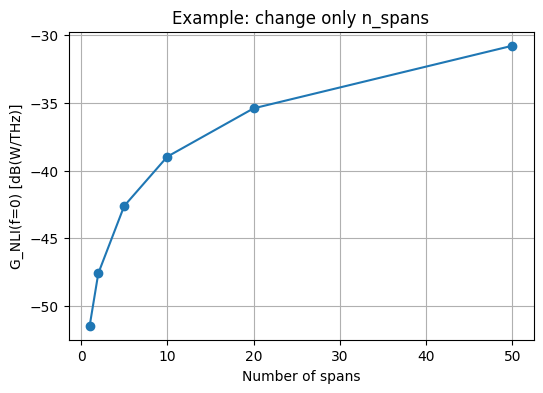

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

span_list = [1, 2, 5, 10, 20, 50]
rows = []
for N in span_list:
    p = params_smf.copy()
    p['n_spans'] = N
    p['sobol_power'] = 16  # 보고서 예제 실행시간 단축
    val = gn.gn_psd_center_single_rect_qmc(**p)
    rows.append({'N_span': N, 'G_NLI_W_per_THz': val})

span_df = pd.DataFrame(rows)
span_df['G_NLI_dB_W_per_THz'] = 10*__import__('numpy').log10(span_df['G_NLI_W_per_THz'])
display(span_df)

plt.figure(figsize=(6,4))
plt.plot(span_df['N_span'], span_df['G_NLI_dB_W_per_THz'], marker='o')
plt.xlabel('Number of spans')
plt.ylabel('G_NLI(f=0) [dB(W/THz)]')
plt.title('Example: change only n_spans')
plt.grid(True)
plt.show()

## 11. Launch power를 바꾸는 예제

In [ ]:
import numpy as np

power_dBm = np.array([-6, -3, 0, 3], dtype=float)
rows = []
for p_dbm in power_dBm:
    power_W = 1e-3 * 10**(p_dbm/10)
    p = params_smf.copy()
    p['power_W'] = power_W
    p['sobol_power'] = 16
    val = gn.gn_psd_center_single_rect_qmc(**p)
    rows.append({'P_dBm': p_dbm, 'P_W': power_W, 'G_NLI_W_per_THz': val})

power_df = pd.DataFrame(rows)
power_df['G_NLI_dB_W_per_THz'] = 10*np.log10(power_df['G_NLI_W_per_THz'])
display(power_df)

,P_dBm,P_W,G_NLI_W_per_THz,G_NLI_dB_W_per_THz
0,-6.0,0.000251,0.000002,-56.975773
1,-3.0,0.000501,0.000016,-47.975773
2,0.0,0.001000,0.000127,-38.975773
3,3.0,0.001995,0.001006,-29.975773


GN integral에서는 PSD가 세 번 곱해지므로 동일 spectrum shape에서

\[
G_{NLI}\propto P^3
\]

입니다. 따라서 launch power를 +3 dB(약 2배) 높이면 NLI는 약 8배(+9 dB) 증가하는 것이 정상입니다.

## 12. 현재 코드에서 **바꿀 수 없는 항목**

아래 항목은 현재 `gn_psd_center_single_rect_qmc()`의 입력값만 바꾸는 것으로는 구현되지 않습니다.

| 항목 | 현재 지원 | 이유 |
|---|---|---|
| WDM channel 수 | ❌ | single-channel PSD만 정의됨 |
| channel spacing | ❌ | 여러 channel center를 생성하지 않음 |
| CUT(channel under test) 선택 | ❌ | 항상 단일 채널 중심 f=0 |
| 채널별 power 차등 | ❌ | 한 개 `power_W`만 사용 |
| RRC / roll-off | ❌ | rectangular PSD 고정 |
| QPSK / 16QAM / 64QAM 입력 | ❌ | pure GN integral 자체에는 constellation 직접 항이 없음 |
| \(\beta_3\) | ❌ | 현재 `phase_mismatch_beta2()`는 \(\beta_2\)만 사용 |
| span마다 다른 fiber | ❌ | 동일 span 가정 |
| ASE / NF / amplifier noise | ❌ | NLI PSD 계산까지만 구현 |
| total SNR | ❌ | ASE + NLI 결합 계층 없음 |
| BER / throughput / capacity | ❌ | system performance 계층 없음 |

따라서 **90 WDM / channel spacing / 64QAM / NF / capacity** 같은 시스템 계산은 현재 코드의 단순 입력 변경만으로는 할 수 없습니다.

## 13. 변조방식에 대한 중요한 해석

현재 코드에 `modulation="QPSK"` 같은 입력이 없는 것은 오류가 아닙니다.

순수 GN model에서는 같은 power와 같은 transmitted PSD를 가정하면 QPSK, 16QAM, 64QAM의 **constellation 자체가 Eq. (G.4)에 직접 들어가지 않습니다.**

변조방식은 이후

- required SNR
- BER
- spectral efficiency
- achievable throughput/capacity

계산에서 사용됩니다.

반대로 constellation 통계가 NLI 자체에 미치는 영향을 직접 반영하려면 GN이 아니라 **EGN correction** 같은 확장이 필요합니다.

## 14. 실무적으로 권장하는 사용 순서

### A. 단일 fiber / 단일 rectangular channel에서 NLI 경향 확인
1. `alpha`, `D`, `gamma`, `baud`, `span length`, `Nspan`, `power` 입력
2. `gn_psd_center_single_rect_qmc()` 실행
3. `sobol_power`를 증가시켜 수렴도 확인
4. `mathematical_self_test()`로 수식 구현 확인

### B. fiber 비교
예: G.652.D vs G.654.E
- 동일 launch power
- 동일 baud
- 동일 span 조건
- `alpha`, `D`, `gamma`만 교체
- \(G_{NLI}\) 비교

### C. span / power sensitivity
- `n_spans` sweep
- `power_W` sweep
- 필요하면 `D`, `gamma`, `alpha` sweep

### D. WDM system / capacity가 목적이라면
현재 파일을 다음 단계로 확장해야 합니다.

```python
WDMSystem(
    n_channels=90,
    symbol_rate_GBd=95,
    channel_spacing_GHz=100,
    rolloff=0.05,
    channel_power_dBm=0,
)
```

처럼 WDM PSD를 생성한 뒤, arbitrary CUT에 대해 Eq. (G.4) 적분을 수행하도록 해야 합니다. 그 다음 ASE/NF, modulation threshold, BER/capacity 계층을 추가해야 합니다.

## 15. 최종 요약

### 현재 `gn_integral.py`를 입력값만 바꿔 바로 활용할 수 있는 범위

\[
\boxed{P, R_s, \alpha, D, \lambda, \gamma, L_s, N_s, QMC\ precision}
\]

을 바꾸면서 **single rectangular channel의 center-frequency NLI PSD**를 비교하는 용도입니다.

### 현재 출력의 핵심

\[
\boxed{G_{NLI}(f=0)\ [W/THz]}
\]

### 현재 코드의 성격

- Eq. (G.4)의 수학 핵심: **범용적으로 재사용 가능**
- 현재 high-level interface: **single-channel 계산용**
- multi-channel WDM / channel spacing / modulation / ASE / capacity: **추가 확장 필요**

즉, 현재 코드는 특정 논문값에 fitting한 코드라기보다 **GN integral core를 검증하고 single-channel 조건에서 재사용할 수 있는 기반 코드**입니다.